In [46]:
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
from pathlib import Path

matplotlib.rcParams.update({
    'font.size': 22,
    'axes.labelsize': 20,
    'legend.fontsize': 18,
    'xtick.labelsize': 18,
    'ytick.labelsize': 20,
})

In [39]:
# Load data
result_dir = Path('results/ssl_clustering')

baseline_sil_values = np.load(result_dir / 'baseline_sil_values.npy')
ours_sil_values = np.load(result_dir / 'ours_sil_values.npy')
sampled_labels = np.load(result_dir / 'sampled_labels.npy')
results_df = pd.read_csv(result_dir / 'silhouette_comparison_results.csv')

baseline_mean = results_df['baseline_silhouette'].values[0]
ours_mean = results_df['ours_silhouette'].values[0]

print(f'Baseline mean: {baseline_mean:.4f}')
print(f'Ours mean:     {ours_mean:.4f}')
print(f'Samples: {len(sampled_labels)} (Natural={np.sum(sampled_labels==0)}, Synthetic={np.sum(sampled_labels==1)})')

Baseline mean: 0.1185
Ours mean:     0.1805
Samples: 5160 (Natural=2580, Synthetic=2580)


In [40]:
def plot_silhouette(ax, sil_values, labels, color, label_name, alpha=0.7, show_cluster_labels=True):
    cluster_names = {0: 'Natural', 1: 'Synthetic'}
    y_lower = 10
    for cluster_id in [0, 1]:
        vals = np.sort(sil_values[labels == cluster_id])
        y_upper = y_lower + len(vals)
        ax.fill_betweenx(
            np.arange(y_lower, y_upper), 0, vals,
            alpha=alpha, color=color,
            label=label_name if cluster_id == 0 else None
        )
        if show_cluster_labels:
            ax.text(-0.05, y_lower + 0.5 * len(vals), cluster_names[cluster_id],
                    fontsize=16, va='center', ha='right')
        y_lower = y_upper + 10

In [41]:
# Shared x-axis limits
x_min = min(baseline_sil_values.min(), ours_sil_values.min()) - 0.05
x_max = max(baseline_sil_values.max(), ours_sil_values.max()) + 0.05

In [42]:
plt.rcParams['font.family'] = 'Arial'

In [ ]:
# Overlaid version (optimized colors)
BASELINE_COLOR_FILL = '#9AA0A6'   # gray
BASELINE_COLOR_LINE = '#5F6368'   # dark gray
OURS_COLOR_FILL = '#4285F4'       # blue
OURS_COLOR_LINE = '#1A73E8'       # dark blue

fig, ax = plt.subplots(figsize=(10, 8))

plot_silhouette(ax, ours_sil_values, sampled_labels,
                color=OURS_COLOR_FILL, label_name='Ours', alpha=0.45,
                show_cluster_labels=False)
plot_silhouette(ax, baseline_sil_values, sampled_labels,
                color=BASELINE_COLOR_LINE, label_name='Baseline', alpha=0.45)


ax.axvline(x=baseline_mean, color=BASELINE_COLOR_LINE, linestyle='--',
           linewidth=3, label=f'Baseline mean ({baseline_mean:.3f})')
ax.axvline(x=ours_mean, color=OURS_COLOR_LINE, linestyle='--',
           linewidth=3, label=f'Ours mean ({ours_mean:.3f})')

ax.set_xlabel('Silhouette Coefficient (cosine)', fontsize=18)
ax.set_ylabel('Samples', fontsize=18)
ax.set_xlim(x_min, x_max)
ax.set_yticks([])
ax.legend(loc='lower right')
plt.tight_layout()

fig.savefig(result_dir / 'silhouette_comparison_overlaid.pdf', dpi=300, bbox_inches='tight')
print('Saved: silhouette_comparison_overlaid.pdf')
plt.show()

Saved: silhouette_comparison_overlaid.png


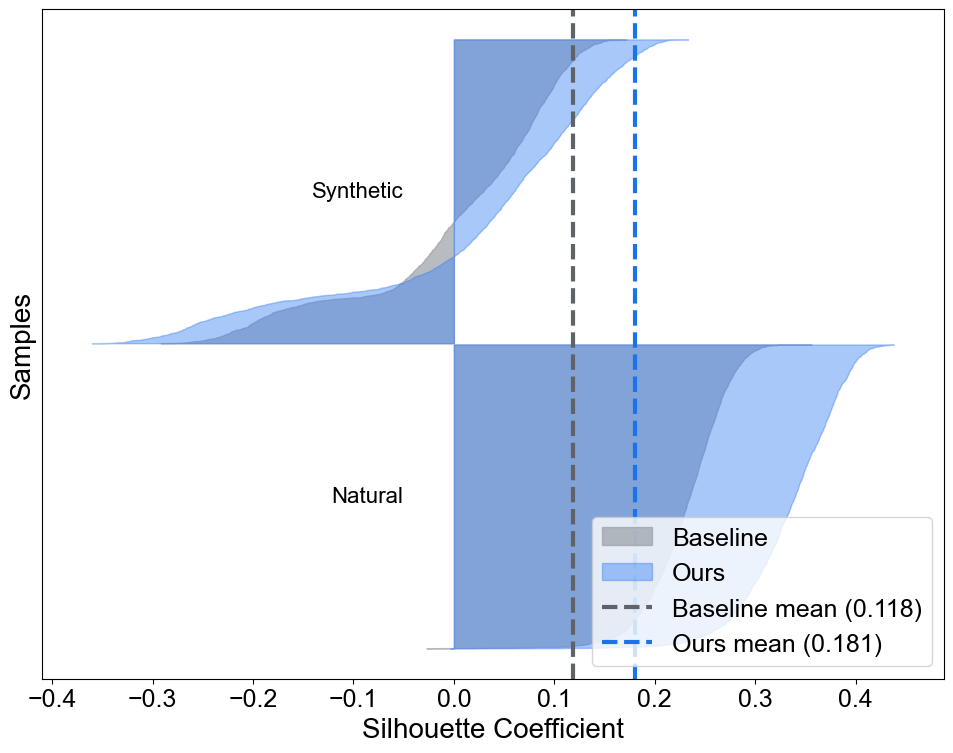

In [54]:
# Overlaid version (optimized colors)
BASELINE_COLOR_FILL = '#9AA0A6'   # gray
BASELINE_COLOR_LINE = '#5F6368'   # dark gray
OURS_COLOR_FILL = '#4285F4'       # blue
OURS_COLOR_LINE = '#1A73E8'       # dark blue

fig, ax = plt.subplots(figsize=(10, 8))


plot_silhouette(ax, baseline_sil_values, sampled_labels,
                color=BASELINE_COLOR_FILL, label_name='Baseline', alpha=0.7)
plot_silhouette(ax, ours_sil_values, sampled_labels,
                color=OURS_COLOR_FILL, label_name='Ours', alpha=0.45,
                show_cluster_labels=False)


ax.axvline(x=baseline_mean, color=BASELINE_COLOR_LINE, linestyle='--',
           linewidth=3, label=f'Baseline mean ({baseline_mean:.3f})')
ax.axvline(x=ours_mean, color=OURS_COLOR_LINE, linestyle='--',
           linewidth=3, label=f'Ours mean ({ours_mean:.3f})')

# Arrow from baseline mean to ours mean
# arrow_y = ax.get_ylim()[1] * 0.5
# ax.annotate('', xy=(ours_mean, arrow_y), xytext=(baseline_mean, arrow_y),
            # arrowprops=dict(arrowstyle='->', color='black', lw=2))

ax.set_xlabel('Silhouette Coefficient', fontsize=20)
ax.set_ylabel('Samples', fontsize=20)
ax.set_xlim(x_min, x_max)
ax.set_yticks([])
ax.legend(loc='lower right', fontsize=18)
plt.tight_layout()

fig.savefig(result_dir / 'silhouette_comparison_overlaid.png', dpi=300, bbox_inches='tight')
print('Saved: silhouette_comparison_overlaid.png')
plt.show()

Saved: silhouette_comparison_subplots.pdf


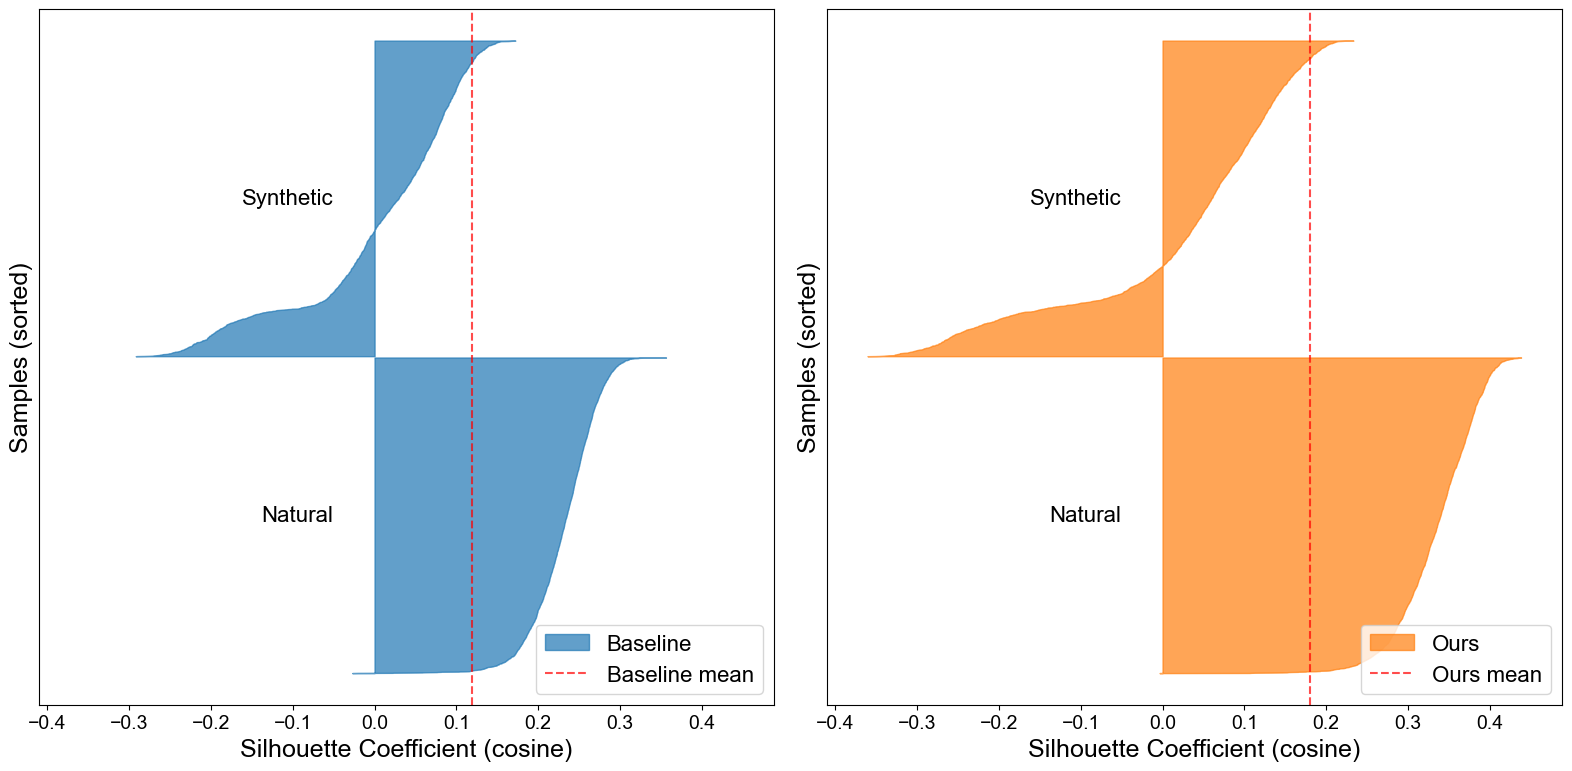

In [ ]:
# # Side-by-side version
# fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 8))

# # Left: Baseline
# plot_silhouette(ax1, baseline_sil_values, sampled_labels,
#                 color='tab:blue', label_name='Baseline', alpha=0.7)
# ax1.axvline(x=baseline_mean, color='red', linestyle='--',
#             linewidth=1.5, alpha=0.7, label='Baseline mean')
# ax1.set_xlabel('Silhouette Coefficient (cosine)')
# ax1.set_ylabel('Samples (sorted)')
# ax1.set_xlim(x_min, x_max)
# ax1.set_yticks([])
# ax1.legend(loc='lower right')

# # Right: Ours
# plot_silhouette(ax2, ours_sil_values, sampled_labels,
#                 color='tab:orange', label_name='Ours', alpha=0.7)
# ax2.axvline(x=ours_mean, color='red', linestyle='--',
#             linewidth=1.5, alpha=0.7, label='Ours mean')
# ax2.set_xlabel('Silhouette Coefficient (cosine)')
# ax2.set_ylabel('Samples (sorted)')
# ax2.set_xlim(x_min, x_max)
# ax2.set_yticks([])
# ax2.legend(loc='lower right')

# plt.tight_layout()

# fig.savefig(result_dir / 'silhouette_comparison_subplots.pdf', dpi=300, bbox_inches='tight')
# print('Saved: silhouette_comparison_subplots.pdf')
# plt.show()

Saved: silhouette_comparison_overlaid_arial.pdf


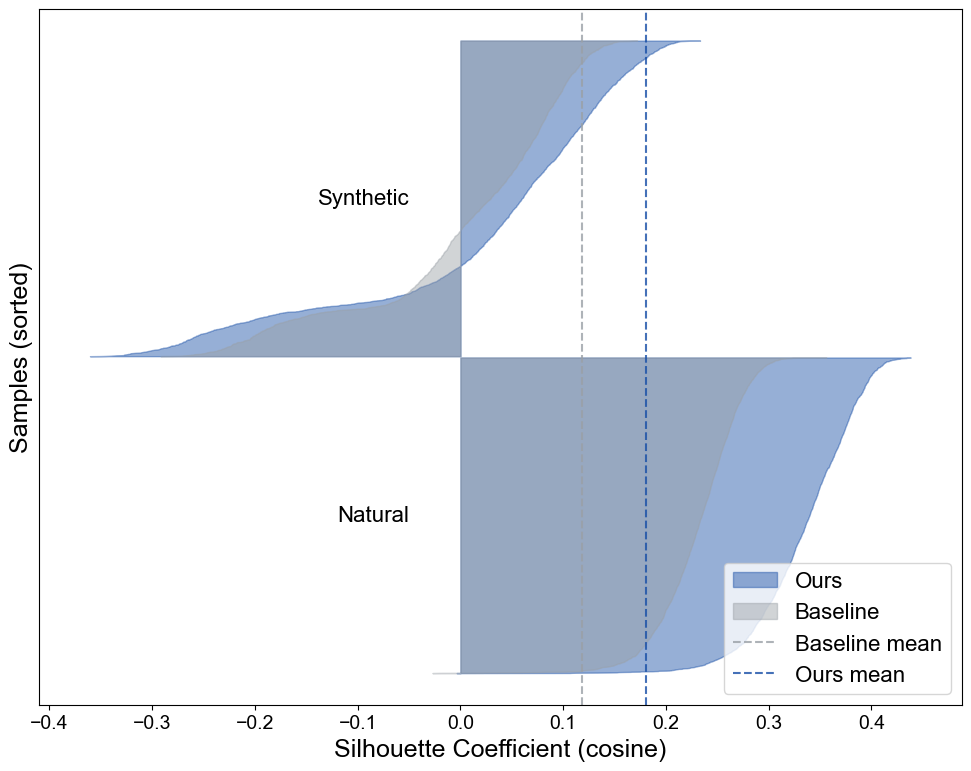

In [19]:
# Arial font + ours color = #E7ECFE
import matplotlib.font_manager as fm

matplotlib.rcParams.update({
    'font.family': 'Arial',
    'font.size': 16,
    'axes.labelsize': 18,
    'legend.fontsize': 16,
    'xtick.labelsize': 14,
    'ytick.labelsize': 14,
})
BASELINE_COLOR = '#9AA0A6'
OURS_COLOR = '#174EA6'

# Overlaid version (Arial, ours=#E7ECFE)
fig, ax = plt.subplots(figsize=(10, 8))

plot_silhouette(ax, ours_sil_values, sampled_labels,
                color=OURS_COLOR, label_name='Ours', alpha=0.45,
                show_cluster_labels=False)
plot_silhouette(ax, baseline_sil_values, sampled_labels,
                color=BASELINE_COLOR, label_name='Baseline', alpha=0.45)


ax.axvline(x=baseline_mean, color=BASELINE_COLOR, linestyle='--',
           linewidth=1.5, alpha=0.8, label='Baseline mean')
ax.axvline(x=ours_mean, color=OURS_COLOR, linestyle='--',
           linewidth=1.5, alpha=0.8, label='Ours mean')

ax.set_xlabel('Silhouette Coefficient (cosine)')
ax.set_ylabel('Samples (sorted)')
ax.set_xlim(x_min, x_max)
ax.set_yticks([])
ax.legend(loc='lower right')
plt.tight_layout()

fig.savefig(result_dir / 'silhouette_comparison_overlaid_arial.pdf', dpi=300, bbox_inches='tight')
print('Saved: silhouette_comparison_overlaid_arial.pdf')
plt.show()

Saved: silhouette_comparison_overlaid_arial.png


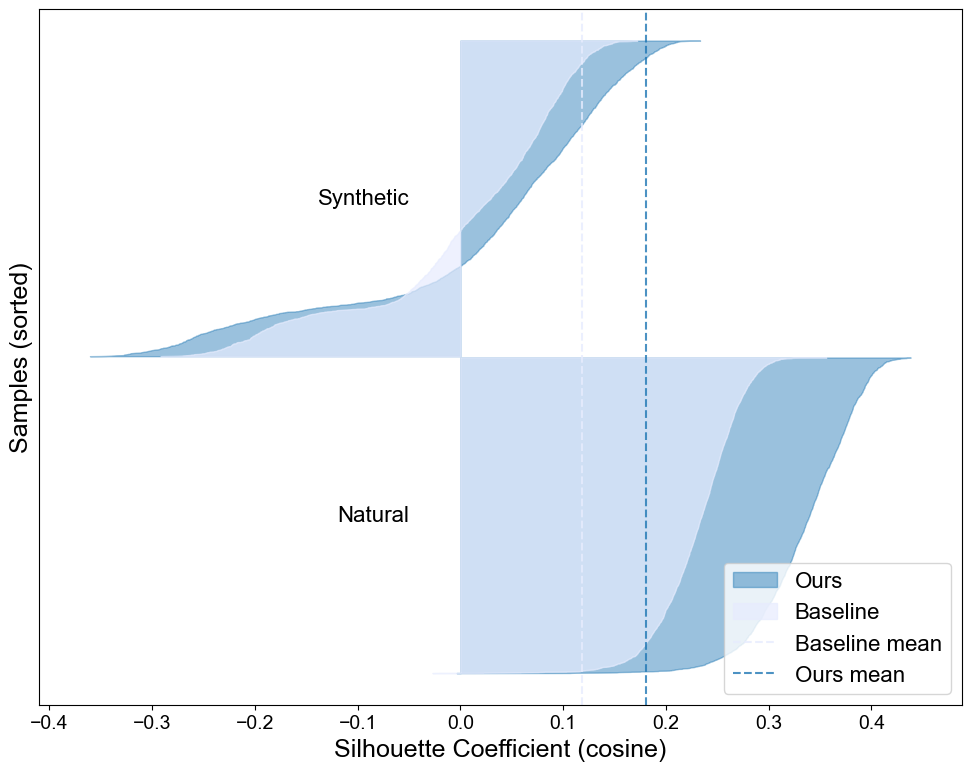

In [15]:
# Arial font + ours color = #E7ECFE
import matplotlib.font_manager as fm

matplotlib.rcParams.update({
    'font.family': 'Arial',
    'font.size': 16,
    'axes.labelsize': 18,
    'legend.fontsize': 16,
    'xtick.labelsize': 14,
    'ytick.labelsize': 14,
})
BASELINE_COLOR = '#E7ECFE'
# OURS_COLOR = '#E7ECFE'

# Overlaid version (Arial, ours=#E7ECFE)
fig, ax = plt.subplots(figsize=(10, 8))

plot_silhouette(ax, ours_sil_values, sampled_labels,
                color='tab:blue', label_name='Ours', alpha=0.45,
                show_cluster_labels=False)
plot_silhouette(ax, baseline_sil_values, sampled_labels,
                color=BASELINE_COLOR, label_name='Baseline', alpha=0.7)


ax.axvline(x=baseline_mean, color=BASELINE_COLOR, linestyle='--',
           linewidth=1.5, alpha=0.8, label='Baseline mean')
ax.axvline(x=ours_mean, color='tab:blue', linestyle='--',
           linewidth=1.5, alpha=0.8, label='Ours mean')

ax.set_xlabel('Silhouette Coefficient (cosine)')
ax.set_ylabel('Samples (sorted)')
ax.set_xlim(x_min, x_max)
ax.set_yticks([])
ax.legend(loc='lower right')
plt.tight_layout()

fig.savefig(result_dir / 'silhouette_comparison_overlaid_arial.png', dpi=300, bbox_inches='tight')
print('Saved: silhouette_comparison_overlaid_arial.png')
plt.show()

In [10]:
OURS_COLOR = "#4285F4"

Saved: silhouette_comparison_subplots_arial.pdf


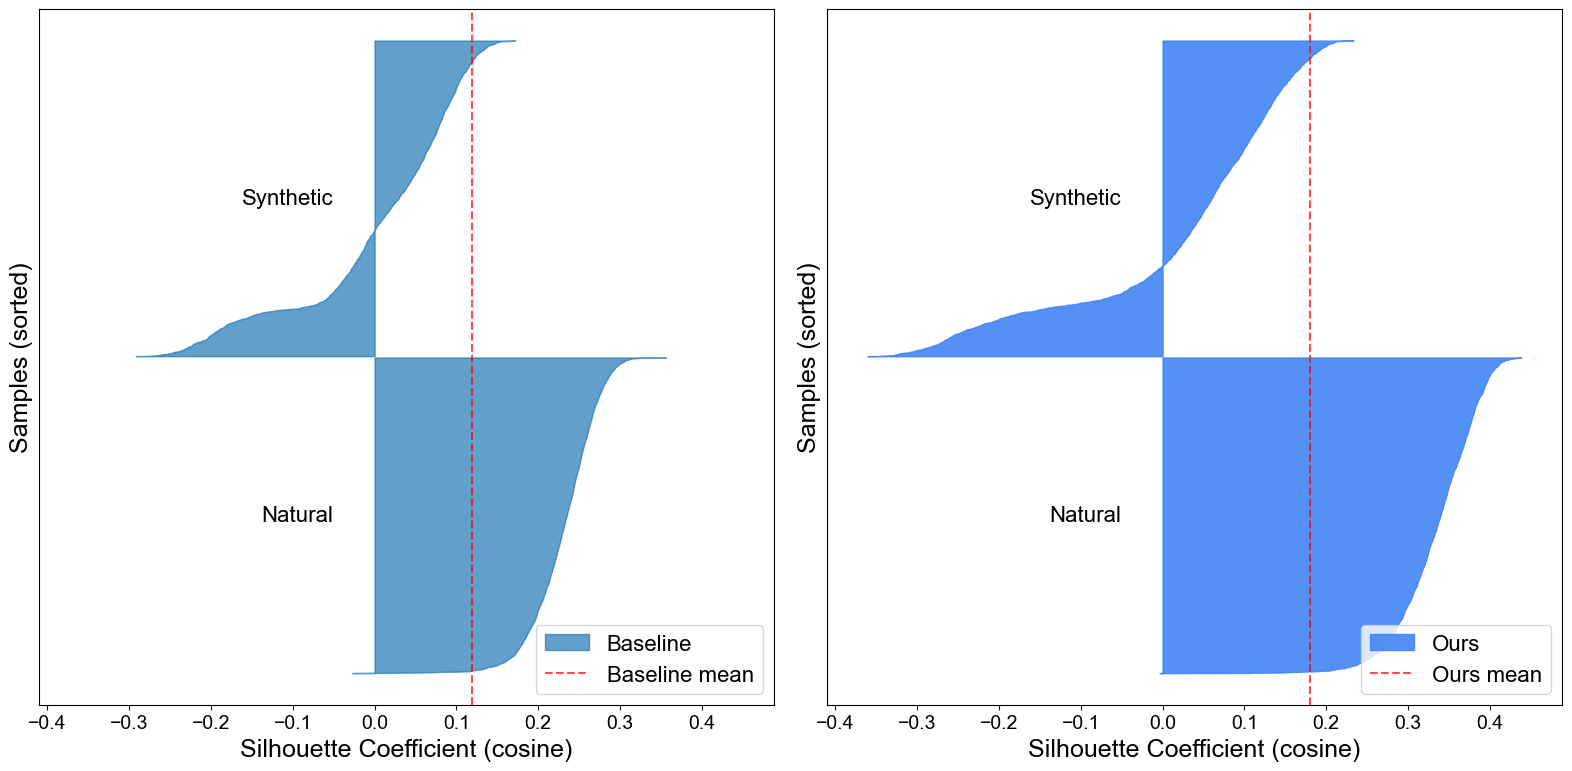

In [11]:
# Side-by-side version (Arial, ours=#E7ECFE)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 8))

# Left: Baseline
plot_silhouette(ax1, baseline_sil_values, sampled_labels,
                color='tab:blue', label_name='Baseline', alpha=0.7)
ax1.axvline(x=baseline_mean, color='red', linestyle='--',
            linewidth=1.5, alpha=0.7, label='Baseline mean')
ax1.set_xlabel('Silhouette Coefficient (cosine)')
ax1.set_ylabel('Samples (sorted)')
ax1.set_xlim(x_min, x_max)
ax1.set_yticks([])
ax1.legend(loc='lower right')

# Right: Ours
plot_silhouette(ax2, ours_sil_values, sampled_labels,
                color=OURS_COLOR, label_name='Ours', alpha=0.9)
ax2.axvline(x=ours_mean, color='red', linestyle='--',
            linewidth=1.5, alpha=0.7, label='Ours mean')
ax2.set_xlabel('Silhouette Coefficient (cosine)')
ax2.set_ylabel('Samples (sorted)')
ax2.set_xlim(x_min, x_max)
ax2.set_yticks([])
ax2.legend(loc='lower right')

plt.tight_layout()

fig.savefig(result_dir / 'silhouette_comparison_subplots_arial.pdf', dpi=300, bbox_inches='tight')
print('Saved: silhouette_comparison_subplots_arial.pdf')
plt.show()

In [ ]:
# === Speaker silhouette: load data & compute ===
from sklearn.metrics import silhouette_samples

# Load common features (.npz float16 -> float32)
baseline_feat = np.load(result_dir / 'common_baseline_features.npz')['data'].astype(np.float32)
ours_feat = np.load(result_dir / 'common_ours_features.npz')['data'].astype(np.float32)
common_labels = np.load(result_dir / 'common_labels.npz')['data']
common_speakers = np.load(result_dir / 'common_speakers.npz', allow_pickle=True)['data']

# Balanced 1:1 nat/syn per speaker
rng = np.random.RandomState(42)
unique_spks = sorted(np.unique(common_speakers))
spk_nat = {s: np.where((common_speakers == s) & (common_labels == 0))[0] for s in unique_spks}
spk_syn = {s: np.where((common_speakers == s) & (common_labels == 1))[0] for s in unique_spks}
n_per_class = min(min(len(spk_nat[s]), len(spk_syn[s])) for s in unique_spks)

bal_idx = []
for s in unique_spks:
    bal_idx.extend(rng.choice(spk_nat[s], n_per_class, replace=False).tolist())
    bal_idx.extend(rng.choice(spk_syn[s], n_per_class, replace=False).tolist())
bal_idx = np.array(bal_idx)

bal_b_feat = baseline_feat[bal_idx]
bal_o_feat = ours_feat[bal_idx]
bal_spk = common_speakers[bal_idx]

print(f'Speakers: {len(unique_spks)}, {n_per_class} nat + {n_per_class} syn per speaker, total: {len(bal_idx)}')

# Per-sample silhouette (speaker clusters, cosine)
b_sil = silhouette_samples(bal_b_feat, bal_spk, metric='cosine')
o_sil = silhouette_samples(bal_o_feat, bal_spk, metric='cosine')

# Per-speaker scores
spk_scores = {}
for s in unique_spks:
    m = bal_spk == s
    spk_scores[s] = {'baseline': np.mean(b_sil[m]), 'ours': np.mean(o_sil[m])}

# 5 speakers where ours loses most
drop5 = sorted(spk_scores, key=lambda s: spk_scores[s]['baseline'] - spk_scores[s]['ours'], reverse=True)[:5]
for s in drop5:
    d = spk_scores[s]['baseline'] - spk_scores[s]['ours']
    print(f"  {s}: baseline={spk_scores[s]['baseline']:.4f}, ours={spk_scores[s]['ours']:.4f}, diff={d:+.4f}")

# Filter to drop5
drop5_set = set(drop5)
drop5_mask = np.array([s in drop5_set for s in bal_spk])
d5_b_sil = b_sil[drop5_mask]
d5_o_sil = o_sil[drop5_mask]
d5_spk = bal_spk[drop5_mask]

print(f'\nDrop5 samples: {len(d5_spk)}')

Saved: silhouette_speaker_largest_drop5_overlaid.pdf


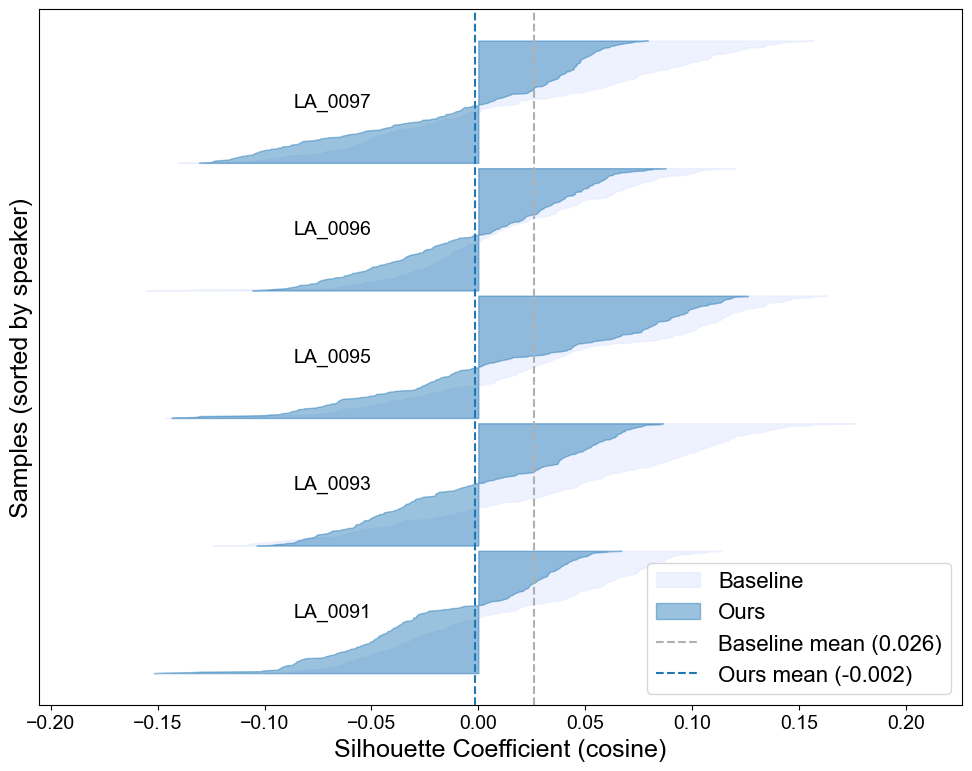

In [13]:
# === Speaker silhouette: overlaid plot (5 speakers, largest drop) ===
LIGHT_COLOR = '#E7ECFE'   # baseline (light)
DARK_COLOR = 'tab:blue'   # ours (dark)

drop5_sorted = sorted(drop5)  # consistent order

fig, ax = plt.subplots(figsize=(10, 8))

y_lower = 10
for i, spk in enumerate(drop5_sorted):
    mask = d5_spk == spk
    b_vals = np.sort(d5_b_sil[mask])
    o_vals = np.sort(d5_o_sil[mask])
    size = len(b_vals)
    y_upper = y_lower + size

    ys = np.arange(y_lower, y_upper)

    # Baseline (light) — draw first so ours overlays
    ax.fill_betweenx(ys, 0, b_vals, alpha=0.7, color=LIGHT_COLOR,
                      label='Baseline' if i == 0 else None)
    # Ours (dark) — draw on top
    ax.fill_betweenx(ys, 0, o_vals, alpha=0.45, color=DARK_COLOR,
                      label='Ours' if i == 0 else None)

    # Speaker label (no parenthetical score)
    ax.text(-0.05, y_lower + 0.5 * size, spk,
            fontsize=14, va='center', ha='right')

    y_lower = y_upper + 10

# Mean lines
b_mean_d5 = np.mean(d5_b_sil)
o_mean_d5 = np.mean(d5_o_sil)
ax.axvline(x=b_mean_d5, color='#B0B0B0', linestyle='--', linewidth=1.5,
           label=f'Baseline mean ({b_mean_d5:.3f})')
ax.axvline(x=o_mean_d5, color=DARK_COLOR, linestyle='--', linewidth=1.5,
           label=f'Ours mean ({o_mean_d5:.3f})')

spk_x_min = min(d5_b_sil.min(), d5_o_sil.min()) - 0.05
spk_x_max = max(d5_b_sil.max(), d5_o_sil.max()) + 0.05
ax.set_xlim(spk_x_min, spk_x_max)
ax.set_xlabel('Silhouette Coefficient (cosine)')
ax.set_ylabel('Samples (sorted by speaker)')
ax.set_yticks([])
ax.legend(loc='lower right')
plt.tight_layout()

fig.savefig(result_dir / 'silhouette_speaker_largest_drop5_overlaid.pdf',
            dpi=300, bbox_inches='tight')
print('Saved: silhouette_speaker_largest_drop5_overlaid.pdf')
plt.show()

Saved: silhouette_speaker_largest_drop5_overlaid.png


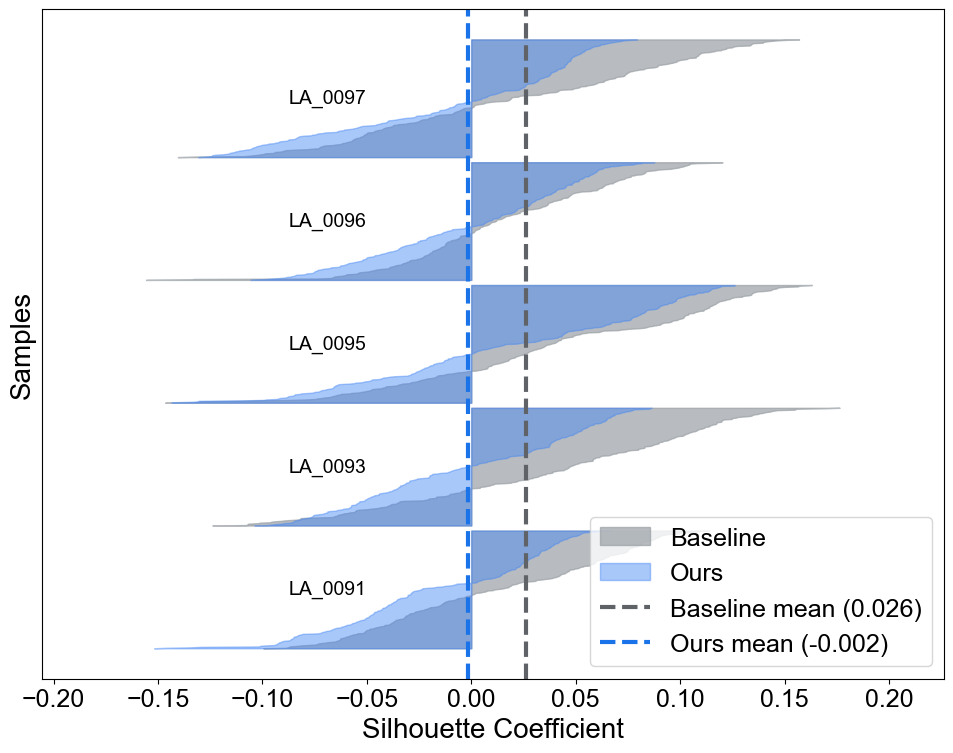

In [52]:
# === Speaker silhouette: overlaid plot (5 speakers, largest drop) ===
LIGHT_COLOR = '#E7ECFE'   # baseline (light)
DARK_COLOR = 'tab:blue'   # ours (dark)

drop5_sorted = sorted(drop5)  # consistent order

fig, ax = plt.subplots(figsize=(10, 8))

y_lower = 10
for i, spk in enumerate(drop5_sorted):
    mask = d5_spk == spk
    b_vals = np.sort(d5_b_sil[mask])
    o_vals = np.sort(d5_o_sil[mask])
    size = len(b_vals)
    y_upper = y_lower + size

    ys = np.arange(y_lower, y_upper)

    # Baseline (light) — draw first so ours overlays
    ax.fill_betweenx(ys, 0, b_vals, alpha=0.7, color=BASELINE_COLOR_FILL,
                      label='Baseline' if i == 0 else None)
    # Ours (dark) — draw on top
    ax.fill_betweenx(ys, 0, o_vals, alpha=0.45, color=OURS_COLOR_FILL,
                      label='Ours' if i == 0 else None)

    # Speaker label (no parenthetical score)
    ax.text(-0.05, y_lower + 0.5 * size, spk,
            fontsize=14, va='center', ha='right')

    y_lower = y_upper + 10

# Mean lines
b_mean_d5 = np.mean(d5_b_sil)
o_mean_d5 = np.mean(d5_o_sil)
ax.axvline(x=b_mean_d5, color=BASELINE_COLOR_LINE, linestyle='--', linewidth=3,
           label=f'Baseline mean ({b_mean_d5:.3f})')
ax.axvline(x=o_mean_d5, color=OURS_COLOR_LINE, linestyle='--', linewidth=3,
           label=f'Ours mean ({o_mean_d5:.3f})')

# Arrow from baseline mean to ours mean
# arrow_y = ax.get_ylim()[1] * 0.5
# ax.annotate('', xy=(o_mean_d5, arrow_y), xytext=(b_mean_d5, arrow_y),
#             arrowprops=dict(arrowstyle='->', color='black', lw=2))

spk_x_min = min(d5_b_sil.min(), d5_o_sil.min()) - 0.05
spk_x_max = max(d5_b_sil.max(), d5_o_sil.max()) + 0.05
ax.set_xlim(spk_x_min, spk_x_max)
ax.set_xlabel('Silhouette Coefficient')
ax.set_ylabel('Samples')
ax.set_yticks([])
ax.legend(loc='lower right')
plt.tight_layout()

fig.savefig(result_dir / 'silhouette_speaker_largest_drop5_overlaid.png',
            dpi=300, bbox_inches='tight')
print('Saved: silhouette_speaker_largest_drop5_overlaid.png')
plt.show()